In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Llama-70B contains approximately 70 billion parameters.
num_parameters = 70_000_000_000

# Number of bytes required by each numerical precision.
bytes_per_dtype = {
    "FP32": 4,
    "FP16": 2,
    "BF16": 2,
}

print(f"Number of parameters: {num_parameters:,}")

Number of parameters: 70,000,000,000


In [ ]:
def bytes_to_gb(num_bytes: float) -> float:
    """
    Convert bytes to decimal gigabytes.

    1 GB = 1,000,000,000 bytes
    """
    return num_bytes / 1_000_000_000


def bytes_to_gib(num_bytes: float) -> float:
    """
    Convert bytes to binary gibibytes.

    1 GiB = 1,073,741,824 bytes
    """
    return num_bytes / (1024 ** 3)


parameter_memory_results = []

for dtype, bytes_per_parameter in bytes_per_dtype.items():
    total_bytes = num_parameters * bytes_per_parameter

    parameter_memory_results.append(
        {
            "Precision": dtype,
            "Bytes per Parameter": bytes_per_parameter,
            "Parameter Memory (GB)": bytes_to_gb(total_bytes),
            "Parameter Memory (GiB)": bytes_to_gib(total_bytes),
        }
    )

parameter_memory_df = pd.DataFrame(parameter_memory_results)

parameter_memory_df

,Precision,Bytes per Parameter,Parameter Memory (GB),Parameter Memory (GiB)
0,FP32,4,280.0,260.770321
1,FP16,2,140.0,130.385160
2,BF16,2,140.0,130.385160


**Calculate training memory**

During training, memory is needed for more than parameters.

We will calculate:

- Parameters
- Gradients
- Adam optimizer states
- FP32 master weights
- Activations

In [8]:
def calculate_training_memory(
    num_parameters: int,
    parameter_bytes: int,
    gradient_bytes: int,
    optimizer_state_bytes: int,
    master_weight_bytes: int = 0,
) -> dict:
    """
    Estimate fixed training memory.

    optimizer_state_bytes represents the total bytes per parameter
    required by all optimizer states.

    For Adam:
    - First moment: 4 bytes
    - Second moment: 4 bytes
    - Total: 8 bytes per parameter
    """

    parameter_memory = num_parameters * parameter_bytes
    gradient_memory = num_parameters * gradient_bytes
    optimizer_memory = num_parameters * optimizer_state_bytes
    master_weight_memory = num_parameters * master_weight_bytes

    total_memory = (
        parameter_memory
        + gradient_memory
        + optimizer_memory
        + master_weight_memory
    )

    return {
        "Parameters (GB)": bytes_to_gb(parameter_memory),
        "Gradients (GB)": bytes_to_gb(gradient_memory),
        "Optimizer States (GB)": bytes_to_gb(optimizer_memory),
        "Master Weights (GB)": bytes_to_gb(master_weight_memory),
        "Total Before Activations (GB)": bytes_to_gb(total_memory),
    }

**Define the training configurations**

In [9]:
training_configurations = {
    "FP32": {
        "parameter_bytes": 4,
        "gradient_bytes": 4,
        "optimizer_state_bytes": 8,
        "master_weight_bytes": 0,
    },
    "FP16 Mixed Precision": {
        "parameter_bytes": 2,
        "gradient_bytes": 2,
        "optimizer_state_bytes": 8,
        "master_weight_bytes": 4,
    },
    "BF16 Mixed Precision": {
        "parameter_bytes": 2,
        "gradient_bytes": 2,
        "optimizer_state_bytes": 8,
        "master_weight_bytes": 4,
    },
}

**Generate the training memory table**

In [10]:
training_memory_results = []

for precision, config in training_configurations.items():
    result = calculate_training_memory(
        num_parameters=num_parameters,
        parameter_bytes=config["parameter_bytes"],
        gradient_bytes=config["gradient_bytes"],
        optimizer_state_bytes=config["optimizer_state_bytes"],
        master_weight_bytes=config["master_weight_bytes"],
    )

    result["Precision"] = precision
    training_memory_results.append(result)

training_memory_df = pd.DataFrame(training_memory_results)

training_memory_df = training_memory_df[
    [
        "Precision",
        "Parameters (GB)",
        "Gradients (GB)",
        "Optimizer States (GB)",
        "Master Weights (GB)",
        "Total Before Activations (GB)",
    ]
]

training_memory_df

,Precision,Parameters (GB),Gradients (GB),Optimizer States (GB),Master Weights (GB),Total Before Activations (GB)
0,FP32,280.0,280.0,560.0,0.0,1120.0
1,FP16 Mixed Precision,140.0,140.0,560.0,280.0,1120.0
2,BF16 Mixed Precision,140.0,140.0,560.0,280.0,1120.0


**Create the required assignment table**

In [11]:
memory_component_table = pd.DataFrame(
    [
        {
            "Memory Component": "Parameters",
            "Why Needed": "Stores the model's learned weights.",
            "Approx Memory for FP32 Llama-70B": "280 GB",
        },
        {
            "Memory Component": "Gradients",
            "Why Needed": "Stores the derivative of the loss with respect to every trainable parameter.",
            "Approx Memory for FP32 Llama-70B": "280 GB",
        },
        {
            "Memory Component": "Optimizer States",
            "Why Needed": "Adam stores the first and second moving averages for every parameter.",
            "Approx Memory for FP32 Llama-70B": "560 GB",
        },
        {
            "Memory Component": "Activations",
            "Why Needed": "Stores intermediate layer outputs required during backpropagation.",
            "Approx Memory for FP32 Llama-70B": "Variable",
        },
    ]
)

memory_component_table

,Memory Component,Why Needed,Approx Memory for FP32 Llama-70B
0,Parameters,Stores the model's learned weights.,280 GB
1,Gradients,Stores the derivative of the loss with respect...,280 GB
2,Optimizer States,Adam stores the first and second moving averag...,560 GB
3,Activations,Stores intermediate layer outputs required dur...,Variable


**Add a simple activation memory estimator**

In [12]:
def estimate_basic_activation_memory(
    batch_size: int,
    sequence_length: int,
    hidden_size: int,
    num_layers: int,
    bytes_per_value: int,
    activation_multiplier: float = 1.0,
) -> float:
    """
    Estimate a basic lower-bound activation memory in GB.

    This simplified estimate assumes one hidden-state tensor per layer.

    Real transformer training normally requires more memory because it also
    stores attention tensors, normalization outputs, MLP intermediates,
    dropout masks, and temporary buffers.
    """

    total_values = (
        batch_size
        * sequence_length
        * hidden_size
        * num_layers
        * activation_multiplier
    )

    total_bytes = total_values * bytes_per_value

    return bytes_to_gb(total_bytes)

In [13]:
example_batch_size = 8
example_sequence_length = 4096
example_hidden_size = 8192
example_num_layers = 80

activation_examples = []

for dtype, bytes_per_value in bytes_per_dtype.items():
    estimated_memory = estimate_basic_activation_memory(
        batch_size=example_batch_size,
        sequence_length=example_sequence_length,
        hidden_size=example_hidden_size,
        num_layers=example_num_layers,
        bytes_per_value=bytes_per_value,
    )

    activation_examples.append(
        {
            "Precision": dtype,
            "Batch Size": example_batch_size,
            "Sequence Length": example_sequence_length,
            "Hidden Size": example_hidden_size,
            "Number of Layers": example_num_layers,
            "Basic Activation Estimate (GB)": estimated_memory,
        }
    )

activation_memory_df = pd.DataFrame(activation_examples)

activation_memory_df

,Precision,Batch Size,Sequence Length,Hidden Size,Number of Layers,Basic Activation Estimate (GB)
0,FP32,8,4096,8192,80,85.899346
1,FP16,8,4096,8192,80,42.949673
2,BF16,8,4096,8192,80,42.949673


**how batch size affects memory**

In [14]:
batch_sizes = [1, 2, 4, 8, 16, 32]

batch_activation_results = []

for batch_size in batch_sizes:
    activation_gb = estimate_basic_activation_memory(
        batch_size=batch_size,
        sequence_length=4096,
        hidden_size=8192,
        num_layers=80,
        bytes_per_value=2,
    )

    batch_activation_results.append(
        {
            "Batch Size": batch_size,
            "Estimated Activation Memory (GB)": activation_gb,
        }
    )

batch_activation_df = pd.DataFrame(batch_activation_results)

batch_activation_df

,Batch Size,Estimated Activation Memory (GB)
0,1,5.368709
1,2,10.737418
2,4,21.474836
3,8,42.949673
4,16,85.899346
5,32,171.798692


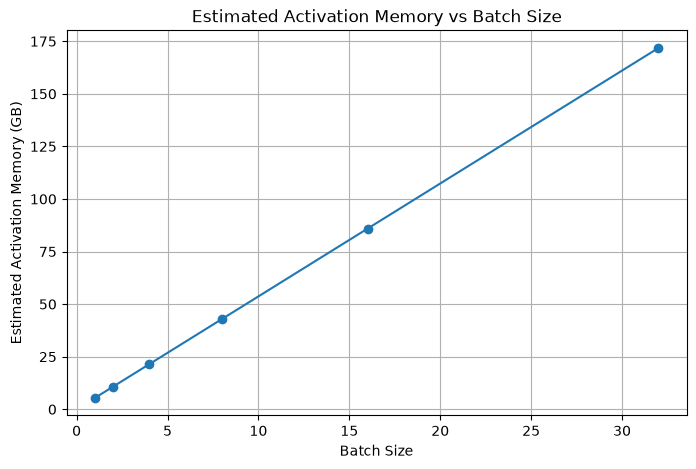

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    batch_activation_df["Batch Size"],
    batch_activation_df["Estimated Activation Memory (GB)"],
    marker="o",
)

plt.title("Estimated Activation Memory vs Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Estimated Activation Memory (GB)")
plt.grid(True)
plt.show()

**how sequence length affects memory**

In [16]:
sequence_lengths = [512, 1024, 2048, 4096, 8192]

sequence_activation_results = []

for sequence_length in sequence_lengths:
    activation_gb = estimate_basic_activation_memory(
        batch_size=8,
        sequence_length=sequence_length,
        hidden_size=8192,
        num_layers=80,
        bytes_per_value=2,
    )

    sequence_activation_results.append(
        {
            "Sequence Length": sequence_length,
            "Estimated Basic Activation Memory (GB)": activation_gb,
        }
    )

sequence_activation_df = pd.DataFrame(sequence_activation_results)

sequence_activation_df

,Sequence Length,Estimated Basic Activation Memory (GB)
0,512,5.368709
1,1024,10.737418
2,2048,21.474836
3,4096,42.949673
4,8192,85.899346


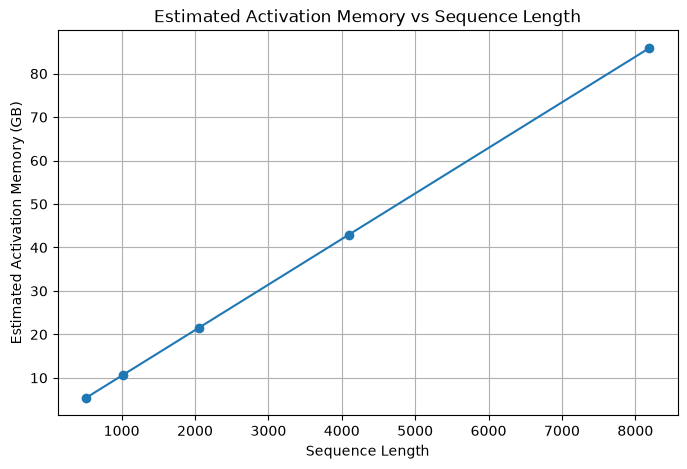

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    sequence_activation_df["Sequence Length"],
    sequence_activation_df["Estimated Basic Activation Memory (GB)"],
    marker="o",
)

plt.title("Estimated Activation Memory vs Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Estimated Activation Memory (GB)")
plt.grid(True)
plt.show()

In [18]:
fp16_parameter_memory_gb = bytes_to_gb(num_parameters * 2)

fp16_training_fixed_memory_gb = training_memory_df.loc[
    training_memory_df["Precision"] == "FP16 Mixed Precision",
    "Total Before Activations (GB)",
].iloc[0]

training_vs_inference_df = pd.DataFrame(
    [
        {
            "Mode": "Inference",
            "Parameters": "Required",
            "Gradients": "Not required",
            "Optimizer States": "Not required",
            "Saved Backprop Activations": "Not required",
            "Approx Fixed Memory": f"{fp16_parameter_memory_gb:.0f} GB plus KV cache and runtime memory",
        },
        {
            "Mode": "Training",
            "Parameters": "Required",
            "Gradients": "Required",
            "Optimizer States": "Required",
            "Saved Backprop Activations": "Required",
            "Approx Fixed Memory": f"{fp16_training_fixed_memory_gb:.0f} GB before activations",
        },
    ]
)

training_vs_inference_df

,Mode,Parameters,Gradients,Optimizer States,Saved Backprop Activations,Approx Fixed Memory
0,Inference,Required,Not required,Not required,Not required,140 GB plus KV cache and runtime memory
1,Training,Required,Required,Required,Required,1120 GB before activations


**No.of GPUs may be required**

In [19]:
import math


def estimate_gpu_count(
    required_memory_gb: float,
    gpu_memory_gb: float,
    utilization_limit: float = 0.90,
) -> int:
    """
    Estimate how many GPUs are required based only on memory capacity.

    utilization_limit leaves space for framework overhead,
    temporary buffers, and communication operations.
    """

    usable_memory_per_gpu = gpu_memory_gb * utilization_limit

    return math.ceil(required_memory_gb / usable_memory_per_gpu)

In [20]:
gpu_memory_options = [24, 40, 48, 80]

gpu_count_results = []

for gpu_memory in gpu_memory_options:
    inference_gpu_count = estimate_gpu_count(
        required_memory_gb=140,
        gpu_memory_gb=gpu_memory,
    )

    training_gpu_count = estimate_gpu_count(
        required_memory_gb=1120,
        gpu_memory_gb=gpu_memory,
    )

    gpu_count_results.append(
        {
            "GPU Memory": f"{gpu_memory} GB",
            "Estimated GPUs for FP16 Parameters Only": inference_gpu_count,
            "Estimated GPUs for FP16 Training Before Activations": training_gpu_count,
        }
    )

gpu_count_df = pd.DataFrame(gpu_count_results)

gpu_count_df

,GPU Memory,Estimated GPUs for FP16 Parameters Only,Estimated GPUs for FP16 Training Before Activations
0,24 GB,7,52
1,40 GB,4,32
2,48 GB,4,26
3,80 GB,2,16


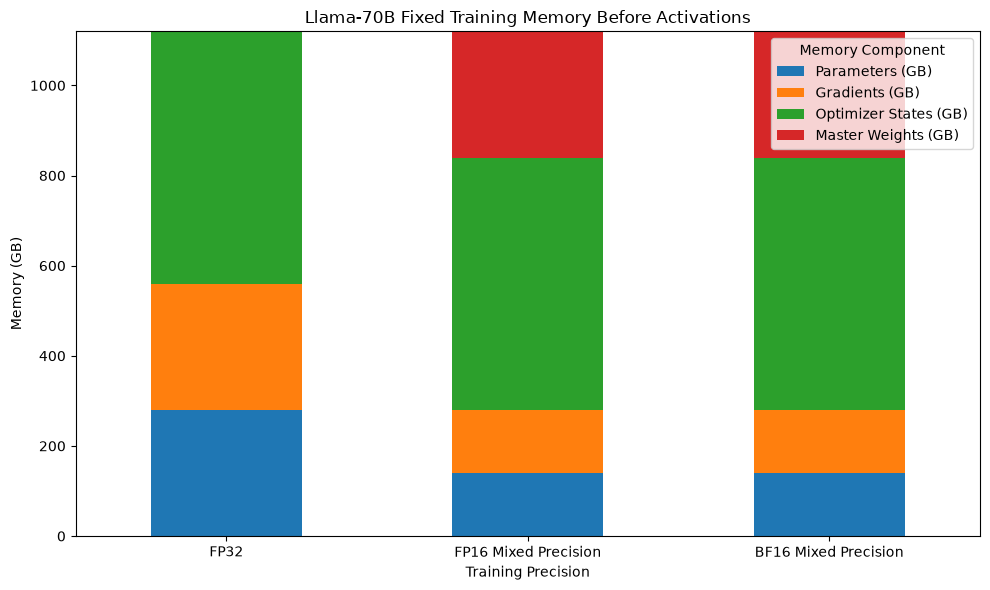

In [21]:
chart_df = training_memory_df.set_index("Precision")[
    [
        "Parameters (GB)",
        "Gradients (GB)",
        "Optimizer States (GB)",
        "Master Weights (GB)",
    ]
]

chart_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
)

plt.title("Llama-70B Fixed Training Memory Before Activations")
plt.xlabel("Training Precision")
plt.ylabel("Memory (GB)")
plt.xticks(rotation=0)
plt.legend(title="Memory Component")
plt.tight_layout()
plt.show()